In [ ]:
#Librerias
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Conexion con drive

from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/Proyecto_TLS/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Datos de implementacion en LINUX
df_tls13 = pd.read_csv(ruta + "dataset_tls_1_3.csv")
df_tls12 = pd.read_csv(ruta + "dataset_tls_1_2.csv")
#Datos de implementacion en MAC
df_tls13mo = pd.read_csv(ruta + "dataset_tls_1_3_mac_open.csv")
df_tls12mo = pd.read_csv(ruta + "dataset_tls_1_2_mac_open.csv")

#Preparación de los datos linux


In [ ]:
#Agregamos las columnas con el protocolo y  el sistema donde se opero

df_tls13["Sistema"] = "Linux"
df_tls13["Protocolo"] = "TLS1.3"
df_tls12["Sistema"] = "Linux"
df_tls12["Protocolo"] = "TLS1.2"

In [ ]:
# Unimos los csv en un gran DataFrame para cada sistema operativo
df = pd.concat([df_tls13, df_tls12], ignore_index=True)
df_mac= pd.concat([df_tls13mo, df_tls12mo], ignore_index=True)


#Limpieza LINUX
df = df[df["status"] == "OK"]
df = df.dropna()
# Limpieza MAC
df_mac = df_mac[df_mac['status'] == 'OK'].copy()
# Eliminar la columna 'fase' del dataframe de Mac
df_mac = df_mac.drop(columns=['Fase'], errors='ignore')
df_mac['handshake_ms'] = pd.to_numeric(df_mac['handshake_ms'], errors='coerce')
df_mac['valor_num'] = pd.to_numeric(df_mac['Valor_o_Latencia'], errors='coerce')


In [ ]:
columnas = ["time_connect", "time_appconnect", "time_total"]

# Procesar Linux
for col in columnas:
    if col in df.columns:
        df[col] = df[col] * 1000

df = df.rename(columns={
    "time_connect": "time_connect_ms",
    "time_appconnect": "time_appconnect_ms",
    "time_total": "time_total_ms"
})


In [ ]:
# 1. Definimos las columnas que queremos que existan en AMBOS
columnas_tiempo = ["time_connect", "time_appconnect", "time_total", "handshake_ms"]

# --- PROCESAR LINUX ---
for col in columnas_tiempo:
    if col in df.columns:
        # Si el promedio es menor a 10, es que está en SEGUNDOS (ej: 0.15) -> multiplicamos
        if df[col].mean() < 10:
            df[col] = df[col] * 1000
    else:
        # Si la columna no existe en Linux, la creamos vacía para que coincida con Mac
        df[col] = pd.NA

# --- PROCESAR MAC ---
for col in columnas_tiempo:
    if col in df_mac.columns:
        # SI EL DATO ES > 10000, ES QUE SE MULTIPLICÓ POR ERROR (como vimos en tu imagen)
        # Lo corregimos dividiendo entre 1000 para regresar a ms reales
        if df_mac[col].mean() > 5000:
            df_mac[col] = df_mac[col] / 1000

        # Si el dato es muy pequeño (< 10), es que venía en segundos -> multiplicamos
        elif df_mac[col].mean() < 10:
            df_mac[col] = df_mac[col] * 1000
    else:
        # Si Mac no tiene la columna (como time_connect), la creamos vacía
        df_mac[col] = pd.NA

# 2. Renombrar todas para que terminen en _ms y sean idénticas
rename_map = {c: f"{c}_ms" if not c.endswith("_ms") else c for c in columnas_tiempo}

df = df.rename(columns=rename_map)
df_mac = df_mac.rename(columns=rename_map)

In [ ]:
#Dataframe de cada variable individual

#Latencia
df_lat = df[df["Variable"] == "Latencia"].copy()
df_lat["Valor"] = pd.to_numeric(df_lat["Valor"], errors="coerce")
df_lat = df_lat.sort_values(by="Valor")

#Perdida
df_perd = df[df["Variable"] == "Perdida"].copy()
df_perd["Valor"] = pd.to_numeric(df_perd["Valor"], errors="coerce")
df_perd = df_perd.sort_values(by="Valor")

#Jitter
df_jit = df[df["Variable"] == "Jitter"].copy()
df_jit["Valor"] = pd.to_numeric(df_jit["Valor"], errors="coerce")
df_jit = df_jit.sort_values(by="Valor")

#Mac

# Separar por variables
df_mac_lat = df_mac[df_mac['Variable_o_Escenario'] == 'Latencia'].sort_values('valor_num')
df_mac_perd = df_mac[df_mac['Variable_o_Escenario'] == 'Perdida']
df_mac_jit = df_mac[df_mac['Variable_o_Escenario'] == 'Jitter']


In [ ]:
#Dataframe para los escenarios

#Servidor internacional
df_serv = df[df["Variable"] == "Servidor_Internacional"].copy()
df_serv["Valor"] = pd.to_numeric(df_serv["Valor"], errors="coerce")
df_serv = df_serv.sort_values(by="Valor")

# Servidor internacional (Mac)
df_mac_serv = df_mac[df_mac['Variable_o_Escenario'] == 'Servidor_Internacional'].copy()
# En Mac, el valor de latencia base para este escenario está en 'Valor_o_Latencia'
df_mac_serv["Valor"] = pd.to_numeric(df_mac_serv["Valor_o_Latencia"], errors="coerce")
df_mac_serv = df_mac_serv.sort_values(by="Iteracion") # Mejor ordenar por iteración aquí


#WiFi_Publico
df_wifi = df[df["Variable"] == "WiFi_Publico"].copy()
df_wifi["Valor"] = pd.to_numeric(df_wifi["Valor"], errors="coerce")
df_wifi = df_wifi.sort_values(by="Valor")

df_mac_wifi = df_mac[df_mac['Variable_o_Escenario'] == 'WiFi_Publico'].copy()
df_mac_wifi["Valor"] = pd.to_numeric(df_mac_wifi["Valor"], errors="coerce")
df_mac_wifi = df_mac_wifi.sort_values(by="Valor")

#Datos_Moviles
df_mov = df[df["Variable"] == "Datos_Moviles"].copy()
df_mov["Valor"] = pd.to_numeric(df_mov["Valor"], errors="coerce")
df_mov = df_mov.sort_values(by="Valor")

df_mac_mov= df_mac[df_mac['Variable_o_Escenario'] == 'Datos_Moviles'].copy()
df_mac_mov["Valor"] = pd.to_numeric(df_mac_mov["Valor"], errors="coerce")
df_mac_mov = df_mac_mov.sort_values(by="Valor")

#Red_Degrada
df_red = df[df["Variable"] == "Red_Degradada"].copy()
df_red["Valor"] = pd.to_numeric(df_red["Valor"], errors="coerce")
df_red = df_red.sort_values(by="Valor")

df_mac_red = df_mac[df_mac['Variable_o_Escenario'] == 'Red_Degradada'].copy()
df_mac_red["Valor"] = pd.to_numeric(df_mac_red["Valor"], errors="coerce")
df_mac_red = df_mac_red.sort_values(by="Valor")





KeyError: 'Valor'

##Metricas de evaluacion

In [ ]:
#Promedio de las iteraciones para cada parametro
prom_lat = df_lat.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()
prom_perd = df_perd.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()
prom_jit = df_jit.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()

##Graficas

###Grafica de promedios (Rregresion)

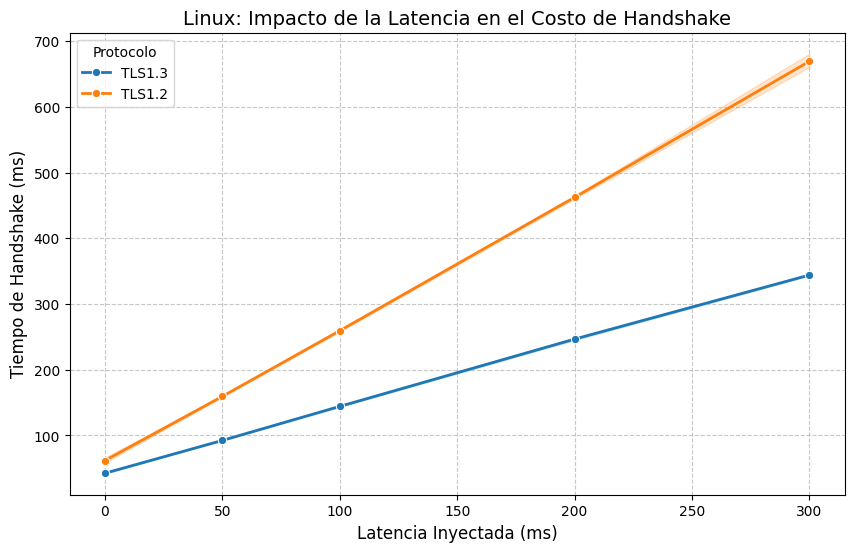

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_lat, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2)

plt.title('Linux: Impacto de la Latencia en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

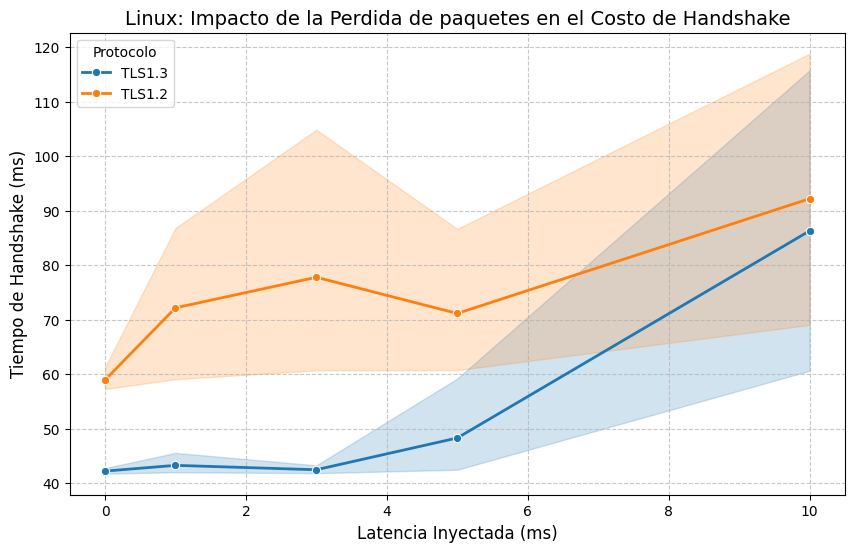

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_perd, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2)

plt.title('Linux: Impacto de la Perdida de paquetes en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

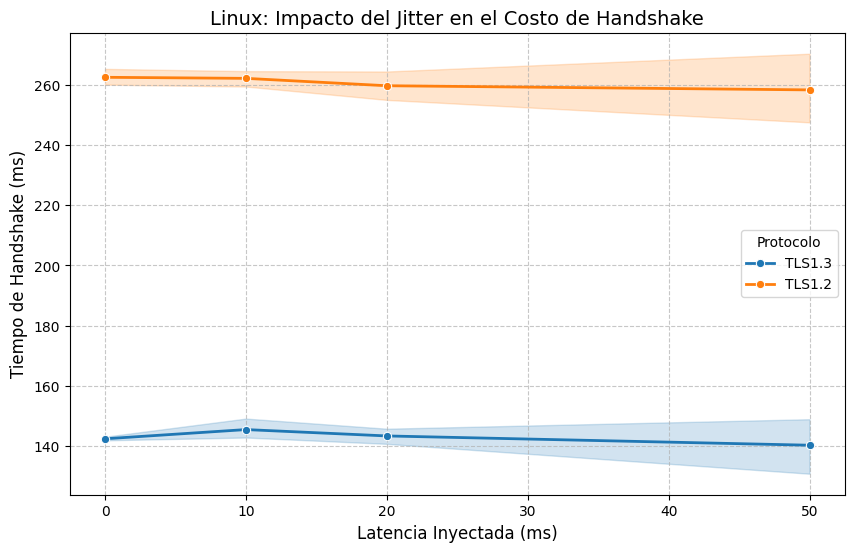

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_jit, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2)

plt.title('Linux: Impacto del Jitter en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

### Graica de datos (Dispersión)

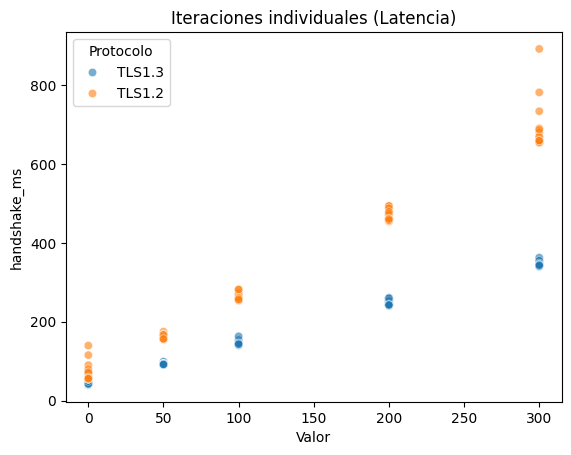

In [ ]:
sns.scatterplot(data=df_lat, x="Valor", y="handshake_ms", hue="Protocolo", alpha=0.6)

plt.title("Iteraciones individuales (Latencia)")
plt.show()

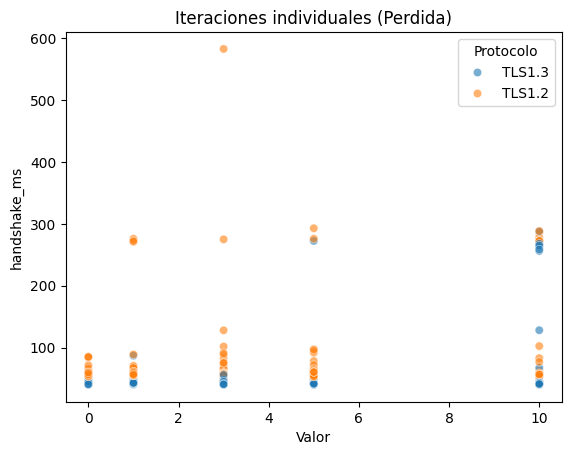

In [ ]:
sns.scatterplot(data=df_perd, x="Valor", y="handshake_ms", hue="Protocolo", alpha=0.6)

plt.title("Iteraciones individuales (Perdida)")
plt.show()

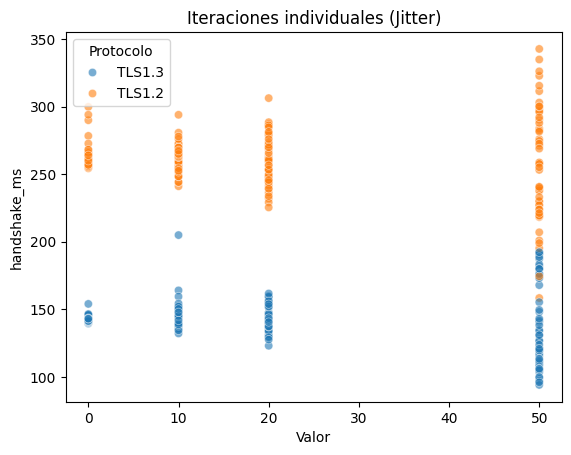

In [ ]:
sns.scatterplot(data=df_jit, x="Valor", y="handshake_ms", hue="Protocolo", alpha=0.6)

plt.title("Iteraciones individuales (Jitter)")
plt.show()

### Graficas de diferencias

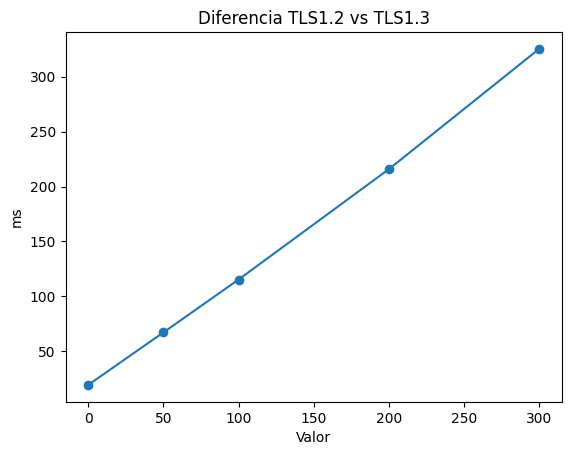

In [ ]:
df_diff = df_lat.groupby(["Valor","Protocolo"])["handshake_ms"].mean().unstack()

df_diff["Diferencia"] = df_diff["TLS1.2"] - df_diff["TLS1.3"]

df_diff["Diferencia"].plot(marker="o")
plt.title("Diferencia TLS1.2 vs TLS1.3")
plt.ylabel("ms")
plt.show()


# MAC

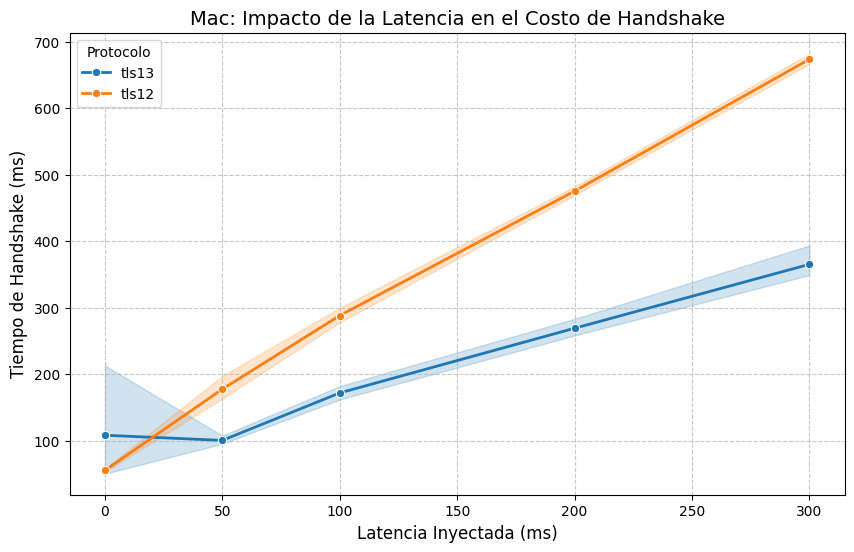

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_mac_lat, x='valor_num', y='handshake_ms', hue='TLS', marker='o', linewidth=2)

plt.title('Mac: Impacto de la Latencia en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

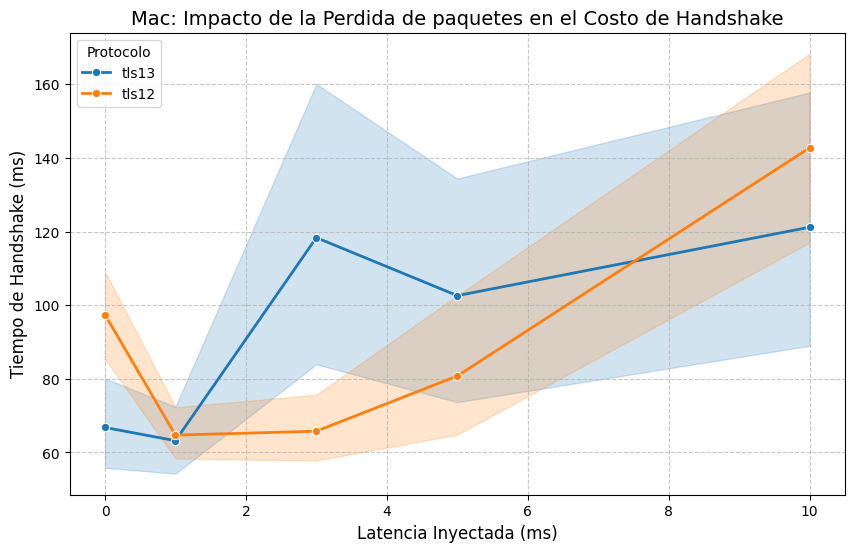

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_mac_perd, x='valor_num', y='handshake_ms', hue='TLS', marker='o', linewidth=2)

plt.title('Mac: Impacto de la Perdida de paquetes en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

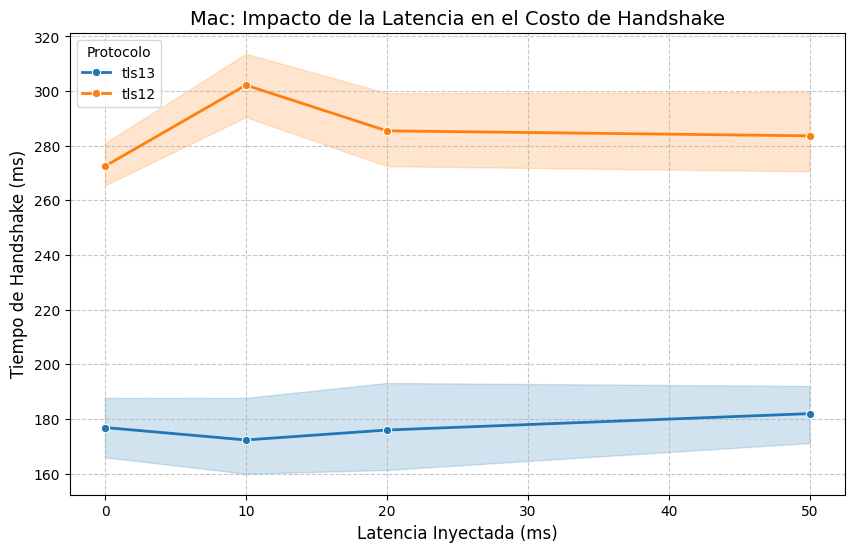

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_mac_jit, x='valor_num', y='handshake_ms', hue='TLS', marker='o', linewidth=2)

plt.title('Mac: Impacto de la Latencia en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

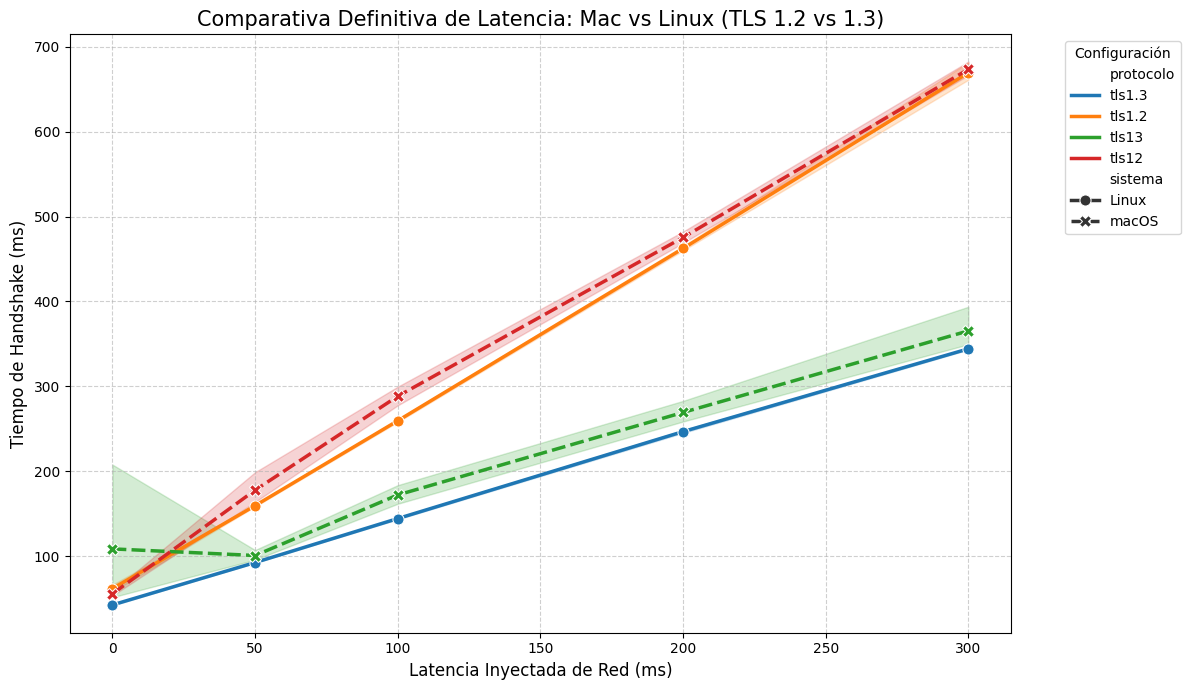

In [ ]:
# Prepare df_lat (Linux latency data)
df_lat_temp = df_lat.copy()
df_lat_temp = df_lat_temp.rename(columns={'Valor': 'valor_num'})
df_lat_temp['sistema'] = df_lat_temp['Sistema']
df_lat_temp['protocolo'] = df_lat_temp['Protocolo'].str.lower()
df_lat_temp = df_lat_temp[['valor_num', 'handshake_ms', 'sistema', 'protocolo']]

# Prepare df_mac_lat (macOS latency data)
df_mac_lat_temp = df_mac_lat.copy()
df_mac_lat_temp = df_mac_lat_temp.rename(columns={'SO': 'sistema', 'TLS': 'protocolo'})
df_mac_lat_temp['protocolo'] = df_mac_lat_temp['protocolo'].str.lower() # Ensure lowercase for consistency
df_mac_lat_temp = df_mac_lat_temp[['valor_num', 'handshake_ms', 'sistema', 'protocolo']]

# Concatenate the two dataframes to create df_total_lat
df_total_lat = pd.concat([df_lat_temp, df_mac_lat_temp], ignore_index=True)

plt.figure(figsize=(12, 7))

# hue da el color, style da el tipo de línea (continua vs punteada)
sns.lineplot(data=df_total_lat,
             x='valor_num',
             y='handshake_ms',
             hue='protocolo',
             style='sistema',
             markers=True,
             linewidth=2.5,
             markersize=8)

plt.title('Comparativa Definitiva de Latencia: Mac vs Linux (TLS 1.2 vs 1.3)', fontsize=15)
plt.xlabel('Latencia Inyectada de Red (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Mejorar la leyenda
plt.legend(title='Configuración', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

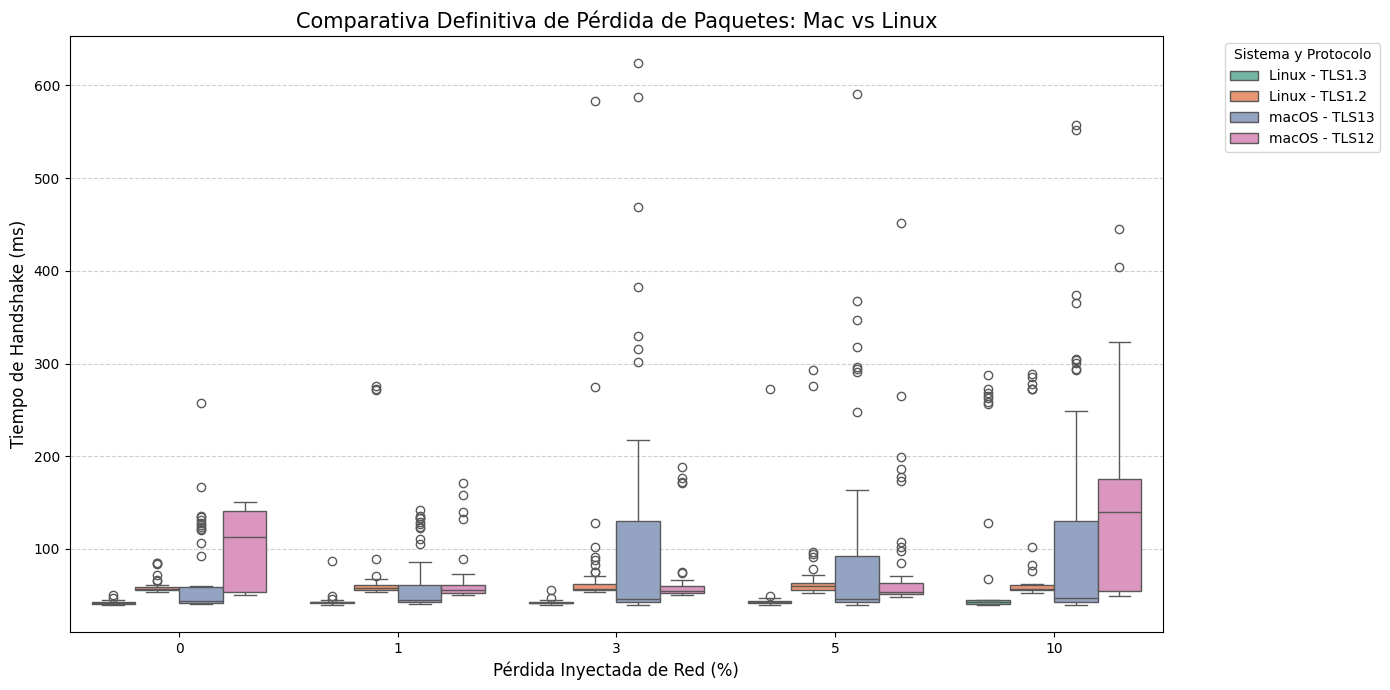

In [ ]:
# 1. Preparar df_perd (Datos de pérdida en Linux)
# Asumiendo que tu DataFrame original de Linux filtrado se llama df_perd
df_perd_temp = df_perd.copy()
df_perd_temp = df_perd_temp.rename(columns={'Valor': 'valor_num'})
df_perd_temp['sistema'] = df_perd_temp['Sistema']
df_perd_temp['protocolo'] = df_perd_temp['Protocolo'].str.upper() # Usamos upper para que diga "TLS 1.3"
df_perd_temp = df_perd_temp[['valor_num', 'handshake_ms', 'sistema', 'protocolo']]

# 2. Preparar df_mac_perd (Datos de pérdida en macOS)
# Asumiendo que tu DataFrame original de Mac filtrado se llama df_mac_perd
df_mac_perd_temp = df_mac_perd.copy()
df_mac_perd_temp = df_mac_perd_temp.rename(columns={'valor': 'valor_num', 'SO': 'sistema', 'TLS': 'protocolo'})
df_mac_perd_temp['protocolo'] = df_mac_perd_temp['protocolo'].str.upper()
df_mac_perd_temp = df_mac_perd_temp[['valor_num', 'handshake_ms', 'sistema', 'protocolo']]

# 3. Concatenar los dos dataframes
df_total_perd = pd.concat([df_perd_temp, df_mac_perd_temp], ignore_index=True)

# 4. Crear una súper-etiqueta para la gráfica de cajas
# Esto creará categorías como "Linux - TLS 1.3" para agrupar los colores correctamente
df_total_perd['Configuracion'] = df_total_perd['sistema'] + ' - ' + df_total_perd['protocolo']

# 5. Generar la Gráfica Combinada
plt.figure(figsize=(14, 7))

# Cambiamos lineplot por boxplot
sns.boxplot(data=df_total_perd,
             x='valor_num',
             y='handshake_ms',
             hue='Configuracion',
             palette='Set2') # Set2 es una paleta de colores amigable para publicaciones

plt.title('Comparativa Definitiva de Pérdida de Paquetes: Mac vs Linux', fontsize=15)
plt.xlabel('Pérdida Inyectada de Red (%)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)

# Grid solo en el eje Y para que los boxplots se vean limpios
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Mejorar la leyenda sacándola un poco del gráfico para que no tape los datos
plt.legend(title='Sistema y Protocolo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


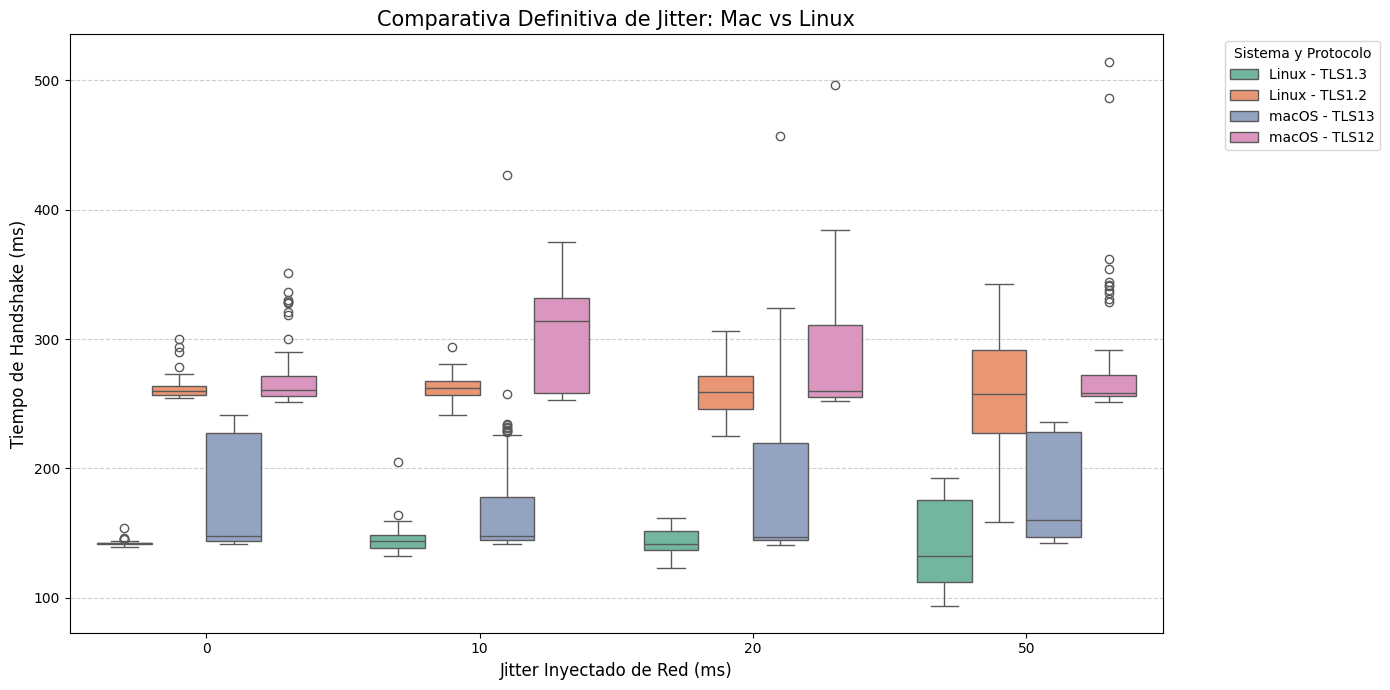

In [ ]:

# 1. Preparar df_jit (Datos de Jitter en Linux)
df_jit_temp = df_jit.copy()
df_jit_temp = df_jit_temp.rename(columns={'Valor': 'valor_num'})
df_jit_temp['sistema'] = df_jit_temp['Sistema']
df_jit_temp['protocolo'] = df_jit_temp['Protocolo'].str.upper()
df_jit_temp = df_jit_temp[['valor_num', 'handshake_ms', 'sistema', 'protocolo']]

# 2. Preparar df_mac_jit (Datos de Jitter en macOS)
df_mac_jit_temp = df_mac_jit.copy()
df_mac_jit_temp = df_mac_jit_temp.rename(columns={'valor': 'valor_num', 'SO': 'sistema', 'TLS': 'protocolo'})
df_mac_jit_temp['protocolo'] = df_mac_jit_temp['protocolo'].str.upper()
df_mac_jit_temp = df_mac_jit_temp[['valor_num', 'handshake_ms', 'sistema', 'protocolo']]

# 3. Concatenar los dos dataframes
df_total_jit = pd.concat([df_jit_temp, df_mac_jit_temp], ignore_index=True)

# 4. Crear la súper-etiqueta para la gráfica de cajas
df_total_jit['Configuracion'] = df_total_jit['sistema'] + ' - ' + df_total_jit['protocolo']

# 5. Generar la Gráfica Combinada
plt.figure(figsize=(14, 7))

sns.boxplot(data=df_total_jit,
             x='valor_num',
             y='handshake_ms',
             hue='Configuracion',
             palette='Set2') # Mantenemos la misma paleta para consistencia visual

plt.title('Comparativa Definitiva de Jitter: Mac vs Linux', fontsize=15)
plt.xlabel('Jitter Inyectado de Red (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)

# Grid solo en el eje Y
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Leyenda ajustada
plt.legend(title='Sistema y Protocolo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()